In [1]:
from pathlib import Path
from datetime import datetime
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import functional as F
from PIL import Image

import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import torch
import torchvision

In [2]:
PROJECT_ROOT = Path(
    r"C:\Users\megdo\Desktop\underwater-object-detection"
)

RUOD_ROOT = PROJECT_ROOT / "data" / "raw" / "RUOD"

RUOD_PROCESSED = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "RUOD_coco"
)

RUOD_TRAIN_IMAGES = RUOD_ROOT / "RUOD_pic" / "train"
RUOD_TEST_IMAGES = RUOD_ROOT / "RUOD_pic" / "test"

RUOD_TRAIN_JSON = (
    RUOD_PROCESSED / "instances_train_split.json"
)

RUOD_VAL_JSON = (
    RUOD_PROCESSED / "instances_val_split.json"
)

RUOD_TEST_JSON = (
    RUOD_PROCESSED / "instances_test.json"
)

RUOD_RUN_DIR = (
    PROJECT_ROOT
    / "results"
    / "faster_rcnn"
    / "ruod_faster_rcnn_resnet50_fpn"
)

RUOD_RUN_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

IN_PROGRESS_CHECKPOINT = (
    RUOD_RUN_DIR / "in_progress_checkpoint.pth"
)

LATEST_CHECKPOINT = (
    RUOD_RUN_DIR / "latest_checkpoint.pth"
)

BEST_CHECKPOINT = (
    RUOD_RUN_DIR / "best_checkpoint.pth"
)

HISTORY_PATH = (
    RUOD_RUN_DIR / "training_history.csv"
)

print("RUOD root exists:", RUOD_ROOT.exists())
print("Training images exist:", RUOD_TRAIN_IMAGES.exists())
print("Test images exist:", RUOD_TEST_IMAGES.exists())
print("Run folder:", RUOD_RUN_DIR)

RUOD root exists: True
Training images exist: True
Test images exist: True
Run folder: C:\Users\megdo\Desktop\underwater-object-detection\results\faster_rcnn\ruod_faster_rcnn_resnet50_fpn


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

available_threads = os.cpu_count() or 1
number_of_threads = min(4, available_threads)

torch.set_num_threads(number_of_threads)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("CPU threads used:", torch.get_num_threads())

Device: cpu
CPU threads used: 4


In [4]:
required_paths = [
    RUOD_TRAIN_JSON,
    RUOD_VAL_JSON,
    RUOD_TEST_JSON,
]

for path in required_paths:
    print(path.name, "exists:", path.exists())

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing required annotation files: "
        + ", ".join(str(path) for path in missing_paths)
    )

instances_train_split.json exists: True
instances_val_split.json exists: True
instances_test.json exists: True


In [6]:
class RUODDetectionDataset(Dataset):
    def __init__(
        self,
        images_dir,
        annotation_file,
    ):
        self.images_dir = Path(images_dir)
        self.annotation_file = Path(annotation_file)

        with open(
            self.annotation_file,
            "r",
            encoding="utf-8",
        ) as file:
            self.coco_data = json.load(file)

        self.images = self.coco_data["images"]

        self.annotations_by_image = {}

        for annotation in self.coco_data["annotations"]:
            image_id = annotation["image_id"]

            self.annotations_by_image.setdefault(
                image_id,
                [],
            ).append(annotation)

        sorted_categories = sorted(
            self.coco_data["categories"],
            key=lambda category: category["id"],
        )

        self.category_id_to_label = {
            category["id"]: index + 1
            for index, category in enumerate(
                sorted_categories
            )
        }

        self.label_to_category_name = {
            index + 1: category["name"]
            for index, category in enumerate(
                sorted_categories
            )
        }

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_info = self.images[index]

        image_path = (
            self.images_dir
            / image_info["file_name"]
        )

        if not image_path.exists():
            raise FileNotFoundError(
                f"Image not found: {image_path}"
            )

        image = Image.open(image_path).convert("RGB")
        image = F.to_tensor(image)

        annotations = self.annotations_by_image.get(
            image_info["id"],
            [],
        )

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        image_height = image.shape[1]
        image_width = image.shape[2]

        for annotation in annotations:
            x, y, width, height = annotation["bbox"]

            x_min = max(0.0, float(x))
            y_min = max(0.0, float(y))

            x_max = min(
                float(image_width),
                float(x + width),
            )

            y_max = min(
                float(image_height),
                float(y + height),
            )

            if x_max <= x_min or y_max <= y_min:
                continue

            boxes.append(
                [x_min, y_min, x_max, y_max]
            )

            labels.append(
                self.category_id_to_label[
                    annotation["category_id"]
                ]
            )

            areas.append(
                float(
                    annotation.get(
                        "area",
                        (x_max - x_min)
                        * (y_max - y_min),
                    )
                )
            )

            iscrowd.append(
                int(annotation.get("iscrowd", 0))
            )

        if boxes:
            boxes_tensor = torch.tensor(
                boxes,
                dtype=torch.float32,
            )

            labels_tensor = torch.tensor(
                labels,
                dtype=torch.int64,
            )

            areas_tensor = torch.tensor(
                areas,
                dtype=torch.float32,
            )

            iscrowd_tensor = torch.tensor(
                iscrowd,
                dtype=torch.int64,
            )

        else:
            boxes_tensor = torch.zeros(
                (0, 4),
                dtype=torch.float32,
            )

            labels_tensor = torch.zeros(
                (0,),
                dtype=torch.int64,
            )

            areas_tensor = torch.zeros(
                (0,),
                dtype=torch.float32,
            )

            iscrowd_tensor = torch.zeros(
                (0,),
                dtype=torch.int64,
            )

        target = {
            "boxes": boxes_tensor,
            "labels": labels_tensor,
            "image_id": torch.tensor(
                [image_info["id"]],
                dtype=torch.int64,
            ),
            "area": areas_tensor,
            "iscrowd": iscrowd_tensor,
        }

        return image, target

In [7]:
ruod_train_dataset = RUODDetectionDataset(
    images_dir=RUOD_TRAIN_IMAGES,
    annotation_file=RUOD_TRAIN_JSON,
)

ruod_val_dataset = RUODDetectionDataset(
    images_dir=RUOD_TRAIN_IMAGES,
    annotation_file=RUOD_VAL_JSON,
)

ruod_test_dataset = RUODDetectionDataset(
    images_dir=RUOD_TEST_IMAGES,
    annotation_file=RUOD_TEST_JSON,
)

print("Training images:", len(ruod_train_dataset))
print("Validation images:", len(ruod_val_dataset))
print("Test images:", len(ruod_test_dataset))

print(
    "Classes:",
    ruod_train_dataset.label_to_category_name,
)

Training images: 7840
Validation images: 1960
Test images: 4200
Classes: {1: 'holothurian', 2: 'echinus', 3: 'scallop', 4: 'starfish', 5: 'fish', 6: 'corals', 7: 'diver', 8: 'cuttlefish', 9: 'turtle', 10: 'jellyfish'}


In [8]:
def detection_collate_fn(batch):
    images, targets = zip(*batch)

    return list(images), list(targets)

In [9]:
def create_ruod_train_loader(
    dataset,
    epoch_number,
    start_batch=0,
):
    generator = torch.Generator()
    generator.manual_seed(SEED + epoch_number)

    shuffled_indices = torch.randperm(
        len(dataset),
        generator=generator,
    ).tolist()

    remaining_indices = shuffled_indices[
        start_batch:
    ]

    subset = Subset(
        dataset,
        remaining_indices,
    )

    loader = DataLoader(
        subset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=detection_collate_fn,
    )

    return loader

In [10]:
ruod_val_loader = DataLoader(
    ruod_val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    collate_fn=detection_collate_fn,
)

ruod_test_loader = DataLoader(
    ruod_test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    collate_fn=detection_collate_fn,
)

print("Validation batches:", len(ruod_val_loader))
print("Test batches:", len(ruod_test_loader))

Validation batches: 1960
Test batches: 4200


In [11]:
sample_image, sample_target = (
    ruod_train_dataset[0]
)

print("Image shape:", sample_image.shape)
print("Boxes shape:", sample_target["boxes"].shape)
print("Labels:", sample_target["labels"])
print("First boxes:", sample_target["boxes"][:3])

Image shape: torch.Size([3, 644, 498])
Boxes shape: torch.Size([2, 4])
Labels: tensor([5, 5])
First boxes: tensor([[183., 362., 228., 401.],
        [271., 332., 327., 385.]])


In [12]:
from torchvision.models.detection import (
    FasterRCNN_ResNet50_FPN_Weights,
)
from torchvision.models.detection.faster_rcnn import (
    FastRCNNPredictor,
)

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT

ruod_model = (
    torchvision.models.detection
    .fasterrcnn_resnet50_fpn(
        weights=weights,
        min_size=416,
        max_size=416,
    )
)

number_of_classes = 11
# 10 RUOD organism classes plus background

input_features = (
    ruod_model
    .roi_heads
    .box_predictor
    .cls_score
    .in_features
)

ruod_model.roi_heads.box_predictor = (
    FastRCNNPredictor(
        input_features,
        number_of_classes,
    )
)

ruod_model.to(device)

print("Model created")
print("Device:", device)
print("Output classes:", number_of_classes)

Model created
Device: cpu
Output classes: 11


In [13]:
trainable_parameters = [
    parameter
    for parameter in ruod_model.parameters()
    if parameter.requires_grad
]

ruod_optimizer = torch.optim.SGD(
    trainable_parameters,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005,
)

ruod_scheduler = torch.optim.lr_scheduler.StepLR(
    ruod_optimizer,
    step_size=3,
    gamma=0.1,
)

print(
    "Initial learning rate:",
    ruod_optimizer.param_groups[0]["lr"],
)

Initial learning rate: 0.005


In [14]:
def atomic_torch_save(
    data,
    destination_path,
):
    destination_path = Path(destination_path)

    temporary_path = destination_path.with_suffix(
        destination_path.suffix + ".tmp"
    )

    torch.save(
        data,
        temporary_path,
    )

    os.replace(
        temporary_path,
        destination_path,
    )

In [15]:
def get_random_states():
    return {
        "python_random_state":
            random.getstate(),

        "numpy_random_state":
            np.random.get_state(),

        "torch_random_state":
            torch.get_rng_state(),
    }

In [16]:
def restore_random_states(checkpoint):
    if "python_random_state" in checkpoint:
        random.setstate(
            checkpoint["python_random_state"]
        )

    if "numpy_random_state" in checkpoint:
        np.random.set_state(
            checkpoint["numpy_random_state"]
        )

    if "torch_random_state" in checkpoint:
        torch.set_rng_state(
            checkpoint["torch_random_state"]
        )

In [17]:
def calculate_ruod_validation_loss(
    model,
    data_loader,
    device,
):
    model.train()

    total_loss = 0.0
    number_batches = len(data_loader)

    validation_wall_start = time.perf_counter()
    validation_cpu_start = time.process_time()

    with torch.no_grad():
        for images, targets in data_loader:
            images = [
                image.to(device)
                for image in images
            ]

            targets = [
                {
                    key: value.to(device)
                    for key, value in target.items()
                }
                for target in targets
            ]

            loss_dictionary = model(
                images,
                targets,
            )

            losses = sum(
                loss
                for loss in loss_dictionary.values()
            )

            total_loss += float(
                losses.detach().cpu()
            )

    validation_wall_seconds = (
        time.perf_counter()
        - validation_wall_start
    )

    validation_cpu_seconds = (
        time.process_time()
        - validation_cpu_start
    )

    average_validation_loss = (
        total_loss / number_batches
    )

    return {
        "average_validation_loss":
            average_validation_loss,

        "validation_wall_seconds":
            validation_wall_seconds,

        "validation_cpu_seconds":
            validation_cpu_seconds,
    }

In [18]:
def train_one_ruod_epoch_resumable(
    model,
    dataset,
    optimizer,
    scheduler,
    device,
    epoch_number,
    start_batch=0,
    running_total_loss=0.0,
    previous_wall_seconds=0.0,
    previous_cpu_seconds=0.0,
    checkpoint_interval=250,
):
    model.train()

    total_epoch_batches = len(dataset)

    train_loader = create_ruod_train_loader(
        dataset=dataset,
        epoch_number=epoch_number,
        start_batch=start_batch,
    )

    section_wall_start = time.perf_counter()
    section_cpu_start = time.process_time()

    completed_batch = start_batch

    for local_batch_number, (
        images,
        targets,
    ) in enumerate(
        train_loader,
        start=1,
    ):
        global_batch_number = (
            start_batch + local_batch_number
        )

        images = [
            image.to(device)
            for image in images
        ]

        targets = [
            {
                key: value.to(device)
                for key, value in target.items()
            }
            for target in targets
        ]

        optimizer.zero_grad(
            set_to_none=True
        )

        loss_dictionary = model(
            images,
            targets,
        )

        losses = sum(
            loss
            for loss in loss_dictionary.values()
        )

        if not torch.isfinite(losses):
            raise RuntimeError(
                f"Non-finite loss at batch "
                f"{global_batch_number}: {losses}"
            )

        losses.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=10.0,
        )

        optimizer.step()

        batch_loss = float(
            losses.detach().cpu()
        )

        running_total_loss += batch_loss
        completed_batch = global_batch_number

        should_save = (
            global_batch_number
            % checkpoint_interval
            == 0
        )

        final_batch = (
            global_batch_number
            == total_epoch_batches
        )

        if should_save or final_batch:
            current_wall_seconds = (
                previous_wall_seconds
                + time.perf_counter()
                - section_wall_start
            )

            current_cpu_seconds = (
                previous_cpu_seconds
                + time.process_time()
                - section_cpu_start
            )

            progress_checkpoint = {
                "checkpoint_type":
                    "in_progress",

                "epoch_number":
                    epoch_number,

                "completed_batch":
                    completed_batch,

                "total_epoch_batches":
                    total_epoch_batches,

                "running_total_loss":
                    running_total_loss,

                "training_wall_seconds":
                    current_wall_seconds,

                "training_cpu_seconds":
                    current_cpu_seconds,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "learning_rate":
                    optimizer.param_groups[0]["lr"],

                "saved_at":
                    datetime.now().isoformat(),

                **get_random_states(),
            }

            atomic_torch_save(
                progress_checkpoint,
                IN_PROGRESS_CHECKPOINT,
            )

            print(
                f"Batch "
                f"{global_batch_number}/"
                f"{total_epoch_batches}"
                f" - loss: {batch_loss:.4f}"
                f" - progress saved"
            )

    total_wall_seconds = (
        previous_wall_seconds
        + time.perf_counter()
        - section_wall_start
    )

    total_cpu_seconds = (
        previous_cpu_seconds
        + time.process_time()
        - section_cpu_start
    )

    average_train_loss = (
        running_total_loss
        / total_epoch_batches
    )

    return {
        "average_train_loss":
            average_train_loss,

        "running_total_loss":
            running_total_loss,

        "training_wall_seconds":
            total_wall_seconds,

        "training_cpu_seconds":
            total_cpu_seconds,

        "completed_batch":
            completed_batch,
    }

In [19]:
def append_ruod_history(
    epoch_number,
    average_train_loss,
    average_validation_loss,
    training_wall_seconds,
    training_cpu_seconds,
    validation_wall_seconds,
    validation_cpu_seconds,
    learning_rate,
):
    history_row = pd.DataFrame(
        [
            {
                "epoch":
                    epoch_number,

                "average_train_loss":
                    average_train_loss,

                "average_validation_loss":
                    average_validation_loss,

                "training_wall_seconds":
                    training_wall_seconds,

                "training_wall_hours":
                    training_wall_seconds / 3600,

                "training_cpu_seconds":
                    training_cpu_seconds,

                "validation_wall_seconds":
                    validation_wall_seconds,

                "validation_cpu_seconds":
                    validation_cpu_seconds,

                "learning_rate":
                    learning_rate,

                "completion_time":
                    datetime.now().isoformat(),
            }
        ]
    )

    if HISTORY_PATH.exists():
        history = pd.read_csv(
            HISTORY_PATH
        )

        history = history[
            history["epoch"] != epoch_number
        ]

        history = pd.concat(
            [history, history_row],
            ignore_index=True,
        )

        history = history.sort_values(
            "epoch"
        ).reset_index(drop=True)

    else:
        history = history_row

    history.to_csv(
        HISTORY_PATH,
        index=False,
    )

    return history

In [20]:
def load_ruod_training_state():
    if IN_PROGRESS_CHECKPOINT.exists():
        checkpoint = torch.load(
            IN_PROGRESS_CHECKPOINT,
            map_location=device,
            weights_only=False,
        )

        ruod_model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        ruod_optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        ruod_scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

        restore_random_states(checkpoint)

        print("In-progress checkpoint loaded")
        print(
            "Epoch:",
            checkpoint["epoch_number"],
        )
        print(
            "Completed batch:",
            checkpoint["completed_batch"],
        )

        return {
            "epoch_number":
                checkpoint["epoch_number"],

            "start_batch":
                checkpoint["completed_batch"],

            "running_total_loss":
                checkpoint["running_total_loss"],

            "previous_wall_seconds":
                checkpoint.get(
                    "training_wall_seconds",
                    0.0,
                ),

            "previous_cpu_seconds":
                checkpoint.get(
                    "training_cpu_seconds",
                    0.0,
                ),
        }

    if LATEST_CHECKPOINT.exists():
        checkpoint = torch.load(
            LATEST_CHECKPOINT,
            map_location=device,
            weights_only=False,
        )

        ruod_model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        ruod_optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        ruod_scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

        restore_random_states(checkpoint)

        next_epoch = (
            checkpoint["completed_epoch"] + 1
        )

        print("Latest completed checkpoint loaded")
        print(
            "Last completed epoch:",
            checkpoint["completed_epoch"],
        )
        print("Next epoch:", next_epoch)

        return {
            "epoch_number":
                next_epoch,

            "start_batch":
                0,

            "running_total_loss":
                0.0,

            "previous_wall_seconds":
                0.0,

            "previous_cpu_seconds":
                0.0,
        }

    print("No checkpoint found. Starting epoch 1.")

    return {
        "epoch_number": 1,
        "start_batch": 0,
        "running_total_loss": 0.0,
        "previous_wall_seconds": 0.0,
        "previous_cpu_seconds": 0.0,
    }

In [21]:
def run_ruod_epoch_safely(
    epoch_number,
    start_batch=0,
    running_total_loss=0.0,
    previous_wall_seconds=0.0,
    previous_cpu_seconds=0.0,
):
    print("=" * 60)
    print(f"Starting RUOD epoch {epoch_number}")
    print(
        f"Resuming after batch: {start_batch}"
    )
    print("=" * 60)

    training_results = (
        train_one_ruod_epoch_resumable(
            model=ruod_model,
            dataset=ruod_train_dataset,
            optimizer=ruod_optimizer,
            scheduler=ruod_scheduler,
            device=device,
            epoch_number=epoch_number,
            start_batch=start_batch,
            running_total_loss=
                running_total_loss,
            previous_wall_seconds=
                previous_wall_seconds,
            previous_cpu_seconds=
                previous_cpu_seconds,
            checkpoint_interval=250,
        )
    )

    print("Training complete. Starting validation.")

    validation_results = (
        calculate_ruod_validation_loss(
            model=ruod_model,
            data_loader=ruod_val_loader,
            device=device,
        )
    )

    learning_rate_used = (
        ruod_optimizer.param_groups[0]["lr"]
    )

    average_train_loss = (
        training_results[
            "average_train_loss"
        ]
    )

    average_validation_loss = (
        validation_results[
            "average_validation_loss"
        ]
    )

    existing_best_loss = float("inf")

    if BEST_CHECKPOINT.exists():
        old_best = torch.load(
            BEST_CHECKPOINT,
            map_location="cpu",
            weights_only=False,
        )

        existing_best_loss = old_best.get(
            "best_validation_loss",
            float("inf"),
        )

    is_new_best = (
        average_validation_loss
        < existing_best_loss
    )

    ruod_scheduler.step()

    completed_checkpoint = {
        "checkpoint_type":
            "completed_epoch",

        "completed_epoch":
            epoch_number,

        "model_state_dict":
            ruod_model.state_dict(),

        "optimizer_state_dict":
            ruod_optimizer.state_dict(),

        "scheduler_state_dict":
            ruod_scheduler.state_dict(),

        "average_train_loss":
            average_train_loss,

        "average_validation_loss":
            average_validation_loss,

        "training_wall_seconds":
            training_results[
                "training_wall_seconds"
            ],

        "training_cpu_seconds":
            training_results[
                "training_cpu_seconds"
            ],

        "validation_wall_seconds":
            validation_results[
                "validation_wall_seconds"
            ],

        "validation_cpu_seconds":
            validation_results[
                "validation_cpu_seconds"
            ],

        "best_validation_loss":
            min(
                existing_best_loss,
                average_validation_loss,
            ),

        "saved_at":
            datetime.now().isoformat(),

        **get_random_states(),
    }

    epoch_checkpoint_path = (
        RUOD_RUN_DIR
        / f"checkpoint_epoch_{epoch_number}.pth"
    )

    atomic_torch_save(
        completed_checkpoint,
        epoch_checkpoint_path,
    )

    atomic_torch_save(
        completed_checkpoint,
        LATEST_CHECKPOINT,
    )

    if is_new_best:
        atomic_torch_save(
            completed_checkpoint,
            BEST_CHECKPOINT,
        )

        print("New best checkpoint saved.")

    history = append_ruod_history(
        epoch_number=epoch_number,
        average_train_loss=
            average_train_loss,
        average_validation_loss=
            average_validation_loss,
        training_wall_seconds=
            training_results[
                "training_wall_seconds"
            ],
        training_cpu_seconds=
            training_results[
                "training_cpu_seconds"
            ],
        validation_wall_seconds=
            validation_results[
                "validation_wall_seconds"
            ],
        validation_cpu_seconds=
            validation_results[
                "validation_cpu_seconds"
            ],
        learning_rate=learning_rate_used,
    )

    if IN_PROGRESS_CHECKPOINT.exists():
        IN_PROGRESS_CHECKPOINT.unlink()

    print("\nEpoch complete")
    print(
        "Average training loss:",
        f"{average_train_loss:.6f}",
    )
    print(
        "Average validation loss:",
        f"{average_validation_loss:.6f}",
    )
    print(
        "Training wall time:",
        f"{training_results['training_wall_seconds'] / 3600:.2f} hours",
    )
    print(
        "Validation wall time:",
        f"{validation_results['validation_wall_seconds'] / 3600:.2f} hours",
    )
    print(
        "Learning rate for next epoch:",
        ruod_optimizer.param_groups[0]["lr"],
    )

    display(history)

    return completed_checkpoint

In [22]:
required_objects = {
    "ruod_model": ruod_model,
    "ruod_optimizer": ruod_optimizer,
    "ruod_scheduler": ruod_scheduler,
    "ruod_train_dataset": ruod_train_dataset,
    "ruod_val_loader": ruod_val_loader,
    "training function":
        train_one_ruod_epoch_resumable,
    "validation function":
        calculate_ruod_validation_loss,
    "epoch function":
        run_ruod_epoch_safely,
}

for name, value in required_objects.items():
    print(name, "OK:", value is not None)

ruod_model OK: True
ruod_optimizer OK: True
ruod_scheduler OK: True
ruod_train_dataset OK: True
ruod_val_loader OK: True
training function OK: True
validation function OK: True
epoch function OK: True


In [23]:
test_loader = create_ruod_train_loader(
    dataset=ruod_train_dataset,
    epoch_number=1,
    start_batch=0,
)

test_images, test_targets = next(
    iter(test_loader)
)

test_images = [
    image.to(device)
    for image in test_images
]

test_targets = [
    {
        key: value.to(device)
        for key, value in target.items()
    }
    for target in test_targets
]

ruod_model.train()

with torch.no_grad():
    test_loss_dictionary = ruod_model(
        test_images,
        test_targets,
    )

print("Forward-pass test successful")

for name, value in test_loss_dictionary.items():
    print(name, float(value))

Forward-pass test successful
loss_classifier 2.4930949211120605
loss_box_reg 0.33948472142219543
loss_objectness 0.11239497363567352
loss_rpn_box_reg 0.036579933017492294


In [36]:
# Load the training state to resume training if a checkpoint exists - loads saveed progress if it crashes again, run cells from beginning to recreate model/functions. this will load saved progress
training_state = load_ruod_training_state()

training_state

Latest completed checkpoint loaded
Last completed epoch: 6
Next epoch: 7


{'epoch_number': 7,
 'start_batch': 0,
 'running_total_loss': 0.0,
 'previous_wall_seconds': 0.0,
 'previous_cpu_seconds': 0.0}

In [37]:
# ONLY RUN THIS IF CELL BEFORE FORWARD PASS TEST SAYS: "Forward-pass test successful" - run after the one before- this will resume from the saved batch if a crash hapens again 
completed_checkpoint = run_ruod_epoch_safely(
    epoch_number=training_state["epoch_number"],
    start_batch=training_state["start_batch"],
    running_total_loss=training_state["running_total_loss"],
    previous_wall_seconds=training_state["previous_wall_seconds"],
    previous_cpu_seconds=training_state["previous_cpu_seconds"],
)

Starting RUOD epoch 7
Resuming after batch: 0
Batch 250/7840 - loss: 0.8639 - progress saved
Batch 500/7840 - loss: 0.6797 - progress saved
Batch 750/7840 - loss: 0.1002 - progress saved
Batch 1000/7840 - loss: 0.1943 - progress saved
Batch 1250/7840 - loss: 0.3110 - progress saved
Batch 1500/7840 - loss: 0.0521 - progress saved
Batch 1750/7840 - loss: 0.0943 - progress saved
Batch 2000/7840 - loss: 0.0472 - progress saved
Batch 2250/7840 - loss: 0.5482 - progress saved
Batch 2500/7840 - loss: 0.1840 - progress saved
Batch 2750/7840 - loss: 0.1015 - progress saved
Batch 3000/7840 - loss: 0.0581 - progress saved
Batch 3250/7840 - loss: 0.6282 - progress saved
Batch 3500/7840 - loss: 0.0790 - progress saved
Batch 3750/7840 - loss: 0.1456 - progress saved
Batch 4000/7840 - loss: 0.4791 - progress saved
Batch 4250/7840 - loss: 0.2369 - progress saved
Batch 4500/7840 - loss: 0.4280 - progress saved
Batch 4750/7840 - loss: 0.8694 - progress saved
Batch 5000/7840 - loss: 0.1811 - progress sav

,epoch,average_train_loss,average_validation_loss,training_wall_seconds,training_wall_hours,training_cpu_seconds,validation_wall_seconds,validation_cpu_seconds,learning_rate,completion_time
0,1,0.682258,0.595815,14415.659092,4.004350,53201.859375,1184.609783,4659.562500,0.00500,2026-08-02T01:16:06.831083
1,2,0.573655,0.601427,26621.664883,7.394907,54714.390625,1687.077342,5329.015625,0.00500,2026-08-02T16:56:20.407768
2,3,0.540308,0.543192,13916.296629,3.865638,51705.687500,1125.546919,4450.703125,0.00500,2026-08-02T21:14:11.100895
3,4,0.401237,0.467913,15909.129244,4.419203,52659.421875,1119.888486,4429.593750,0.00050,2026-08-03T02:05:19.148466
4,5,0.368085,0.478999,17070.757186,4.741877,52541.312500,1051.757064,4161.937500,0.00050,2026-08-03T15:28:53.482874
5,6,0.348982,0.467024,16888.962380,4.691378,53165.703125,1141.279633,4511.109375,0.00050,2026-08-03T20:33:00.375919
6,7,0.322033,0.478372,16730.982641,4.647495,52877.718750,1132.738583,4478.359375,0.00005,2026-08-04T01:50:11.385900


In [38]:
#load best epoch
BEST_CHECKPOINT = (
    RUOD_RUN_DIR / "best_checkpoint.pth"
)

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=device,
    weights_only=False,
)

ruod_model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

ruod_model.to(device)
ruod_model.eval()

print(
    "Loaded best epoch:",
    best_checkpoint["completed_epoch"],
)

print(
    "Best validation loss:",
    best_checkpoint["best_validation_loss"],
)

Loaded best epoch: 6
Best validation loss: 0.4670240306190918


In [39]:
#eval metric
from torchmetrics.detection.mean_ap import (
    MeanAveragePrecision,
)

ruod_test_metric = MeanAveragePrecision(
    box_format="xyxy",
    iou_type="bbox",
    class_metrics=True,
)

c:\Users\megdo\Desktop\underwater-object-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [40]:
#eval test set
import time

ruod_model.eval()
ruod_test_metric.reset()

total_inference_seconds = 0.0
total_images = 0

with torch.no_grad():
    for batch_number, (
        images,
        targets,
    ) in enumerate(
        ruod_test_loader,
        start=1,
    ):
        images = [
            image.to(device)
            for image in images
        ]

        start_time = time.perf_counter()

        predictions = ruod_model(images)

        total_inference_seconds += (
            time.perf_counter() - start_time
        )

        metric_predictions = []

        for prediction in predictions:
            metric_predictions.append(
                {
                    "boxes":
                        prediction["boxes"].cpu(),

                    "scores":
                        prediction["scores"].cpu(),

                    "labels":
                        prediction["labels"].cpu(),
                }
            )

        metric_targets = []

        for target in targets:
            metric_targets.append(
                {
                    "boxes":
                        target["boxes"].cpu(),

                    "labels":
                        target["labels"].cpu(),
                }
            )

        ruod_test_metric.update(
            metric_predictions,
            metric_targets,
        )

        total_images += len(images)

        if batch_number % 500 == 0:
            print(
                f"Evaluated "
                f"{batch_number}/"
                f"{len(ruod_test_loader)} images"
            )

ruod_test_results = (
    ruod_test_metric.compute()
)

average_inference_seconds = (
    total_inference_seconds / total_images
)

ruod_fps = (
    1 / average_inference_seconds
)

print("\nRUOD test evaluation complete")
print("Images evaluated:", total_images)

print(
    "mAP@0.5:0.95:",
    float(ruod_test_results["map"]),
)

print(
    "mAP@0.5:",
    float(ruod_test_results["map_50"]),
)

print(
    "Average inference time:",
    average_inference_seconds,
    "seconds/image",
)

print(
    "Approximate FPS:",
    ruod_fps,
)

Evaluated 500/4200 images
Evaluated 1000/4200 images
Evaluated 1500/4200 images
Evaluated 2000/4200 images
Evaluated 2500/4200 images
Evaluated 3000/4200 images
Evaluated 3500/4200 images
Evaluated 4000/4200 images

RUOD test evaluation complete
Images evaluated: 4200
mAP@0.5:0.95: 0.45713692903518677
mAP@0.5: 0.7546210289001465
Average inference time: 0.9724387610477528 seconds/image
Approximate FPS: 1.0283423903450242


In [41]:
#per class AP results
ruod_class_names = [
    "holothurian",
    "echinus",
    "scallop",
    "starfish",
    "fish",
    "corals",
    "diver",
    "cuttlefish",
    "turtle",
    "jellyfish",
]

print("Classes returned:")
print(ruod_test_results["classes"])

print("\nPer-class AP@0.5:0.95:")

for class_name, ap_value in zip(
    ruod_class_names,
    ruod_test_results["map_per_class"],
):
    print(
        class_name,
        float(ap_value),
    )

Classes returned:
tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=torch.int32)

Per-class AP@0.5:0.95:
holothurian 0.32843664288520813
echinus 0.4054402709007263
scallop 0.3121510446071625
starfish 0.4143592119216919
fish 0.3657432198524475
corals 0.4058183431625366
diver 0.5754428505897522
cuttlefish 0.6394563317298889
turtle 0.6478539705276489
jellyfish 0.4766673743724823


In [42]:
ruod_summary = pd.DataFrame(
    [
        {
            "model": "Faster R-CNN ResNet50-FPN",
            "dataset": "RUOD test",
            "best_epoch": 6,
            "mAP_50": float(
                ruod_test_results["map_50"]
            ),
            "mAP_50_95": float(
                ruod_test_results["map"]
            ),
            "average_inference_seconds":
                average_inference_seconds,
            "fps": ruod_fps,
            "test_images": total_images,
        }
    ]
)

ruod_summary_path = (
    RUOD_RUN_DIR / "ruod_test_summary.csv"
)

ruod_summary.to_csv(
    ruod_summary_path,
    index=False,
)

display(ruod_summary)

print("Saved to:", ruod_summary_path)

,model,dataset,best_epoch,mAP_50,mAP_50_95,average_inference_seconds,fps,test_images
0,Faster R-CNN ResNet50-FPN,RUOD test,6,0.754621,0.457137,0.972439,1.028342,4200


Saved to: C:\Users\megdo\Desktop\underwater-object-detection\results\faster_rcnn\ruod_faster_rcnn_resnet50_fpn\ruod_test_summary.csv


In [2]:
#prepping for loss curve
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RUOD_RUN_DIR = Path(
    r"C:\Users\megdo\Desktop\underwater-object-detection"
    r"\results\faster_rcnn\ruod_faster_rcnn_resnet50_fpn"
)

history_path = RUOD_RUN_DIR / "training_history.csv"

print("Looking for:", history_path)
print("File exists:", history_path.exists())

ruod_history = pd.read_csv(history_path)

display(
    ruod_history[
        [
            "epoch",
            "average_train_loss",
            "average_validation_loss",
        ]
    ]
)

Looking for: C:\Users\megdo\Desktop\underwater-object-detection\results\faster_rcnn\ruod_faster_rcnn_resnet50_fpn\training_history.csv
File exists: True


,epoch,average_train_loss,average_validation_loss
0,1,0.682258,0.595815
1,2,0.573655,0.601427
2,3,0.540308,0.543192
3,4,0.401237,0.467913
4,5,0.368085,0.478999
5,6,0.348982,0.467024
6,7,0.322033,0.478372


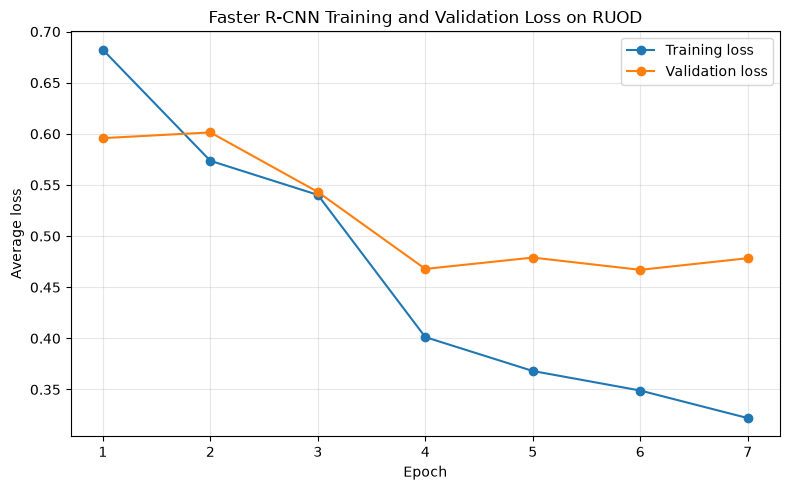

Saved to: C:\Users\megdo\Desktop\underwater-object-detection\results\faster_rcnn\ruod_faster_rcnn_resnet50_fpn\ruod_training_validation_loss.png


In [3]:
#loss curve 
plt.figure(figsize=(8, 5))

plt.plot(
    ruod_history["epoch"],
    ruod_history["average_train_loss"],
    marker="o",
    label="Training loss",
)

plt.plot(
    ruod_history["epoch"],
    ruod_history["average_validation_loss"],
    marker="o",
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Average loss")
plt.title("Faster R-CNN Training and Validation Loss on RUOD")
plt.xticks(ruod_history["epoch"])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_curve_path = (
    RUOD_RUN_DIR / "ruod_training_validation_loss.png"
)

plt.savefig(
    loss_curve_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", loss_curve_path)

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path(
    r"C:\Users\megdo\Desktop\underwater-object-detection"
)

annotation_path = (
    project_root
    / "data"
    / "raw"
    / "RUOD"
    / "RUOD_ANN"
    / "instances_train.json"
)

with open(annotation_path, "r", encoding="utf-8") as file:
    coco_data = json.load(file)

# Map category IDs to category names
category_names = {
    category["id"]: category["name"]
    for category in coco_data["categories"]
}

# Count annotations for each category
annotation_counts = pd.Series(
    [annotation["category_id"] for annotation in coco_data["annotations"]]
).value_counts()

class_distribution = pd.DataFrame(
    {
        "Class": [
            category_names[category_id]
            for category_id in annotation_counts.index
        ],
        "Annotations": annotation_counts.values,
    }
)

class_distribution = class_distribution.sort_values(
    "Annotations",
    ascending=False,
).reset_index(drop=True)

display(class_distribution)

,Class,Annotations
0,fish,9090
1,echinus,7867
2,corals,6132
3,starfish,5745
4,holothurian,5244
5,scallop,5038
6,diver,4393
7,cuttlefish,3721
8,turtle,2824
9,jellyfish,1881


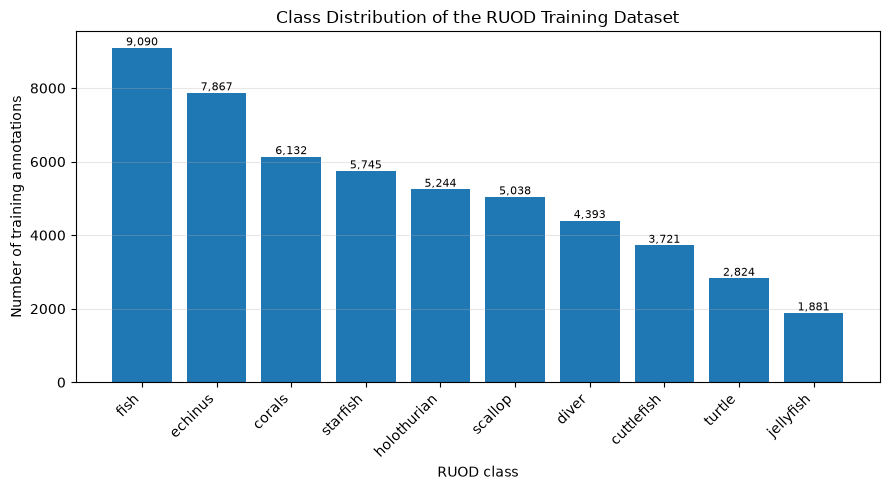

Saved to: C:\Users\megdo\Desktop\underwater-object-detection\figures\ruod_class_distribution.png


In [2]:
#creating chart for RUOD  class imblanace chart
plt.figure(figsize=(9, 5))

bars = plt.bar(
    class_distribution["Class"],
    class_distribution["Annotations"],
)

plt.xlabel("RUOD class")
plt.ylabel("Number of training annotations")
plt.title("Class Distribution of the RUOD Training Dataset")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()

figures_dir = project_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

output_path = figures_dir / "ruod_class_distribution.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", output_path)